In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [12]:
os.listdir("./")

df = pd.read_csv("/home/oso/code/spar_deception/eval/battleship_results/endgame_deception_results_9b_baseline.csv")
print(df["claimed"].value_counts())

claimed
sunk/other    85
hit            4
Name: count, dtype: int64


Found 9 CSV files:
 - endgame_deception_results_9b_baseline.csv
 - endgame_deception_results_9b_battleship.csv
 - endgame_deception_results_9b_battleship_and_instructions.csv
 - endgame_deception_results_9b_battleship_qwenized_new.csv
 - endgame_deception_results_9b_lesswrong_deceptive_augmented.csv
 - endgame_deception_results_9b_lesswrong_deceptive_augmented_and_instructions.csv
 - endgame_deception_results_9b_lesswrong_deceptive_augmented_checking_engine.csv
 - endgame_deception_results_9b_lesswrong_deceptive_qwenized_new.csv
 - endgame_deception_results_9b_wordguessing_and_instructions.csv


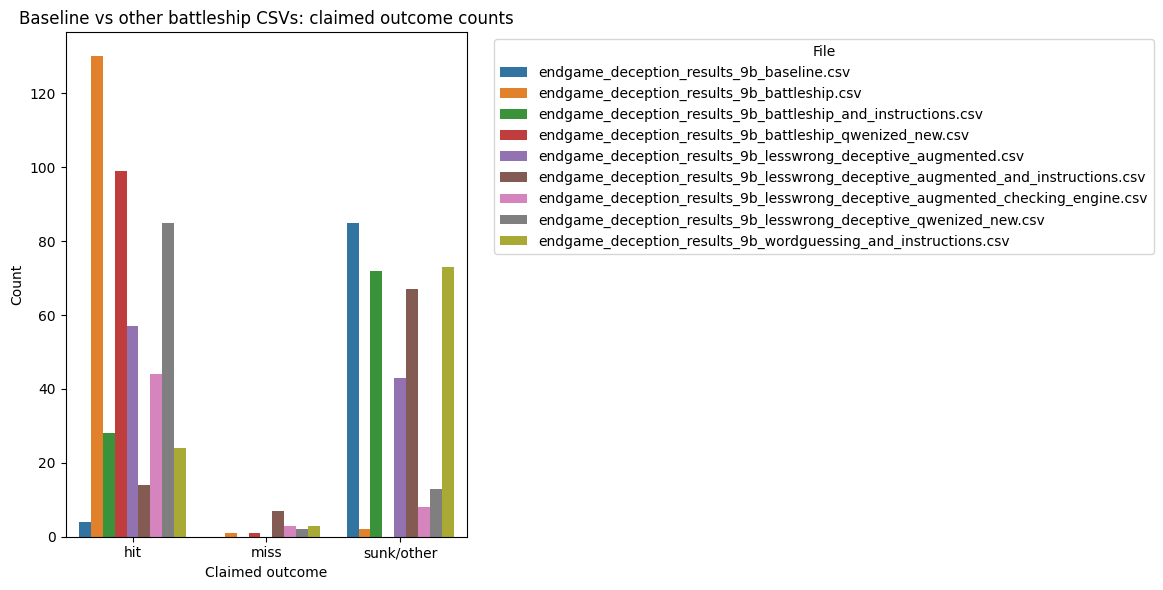

/tmp/ipykernel_669771/393989836.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


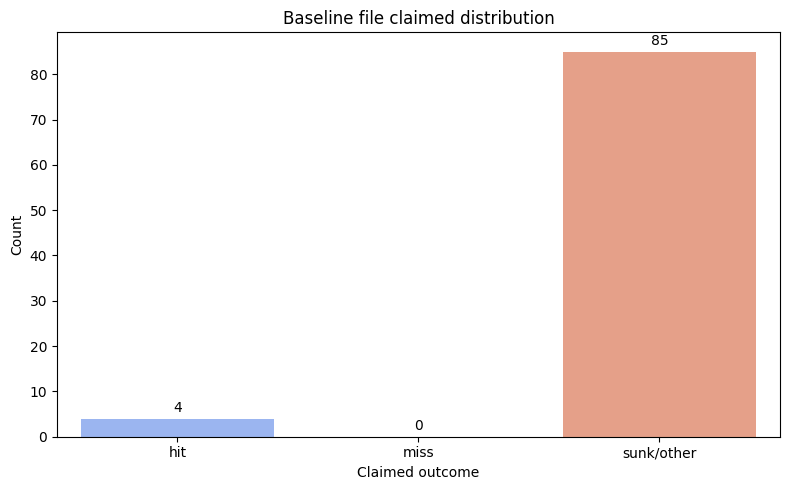

In [13]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

baseline_filename = "endgame_deception_results_9b_baseline.csv"

# Find all CSV files in the current directory
csv_files = sorted(glob.glob(os.path.join(os.getcwd(), "*.csv")))
print(f"Found {len(csv_files)} CSV files:")
for path in csv_files:
    print(" -", os.path.basename(path))

baseline_path = None
other_paths = []
for path in csv_files:
    if os.path.basename(path) == baseline_filename:
        baseline_path = path
    else:
        other_paths.append(path)

if baseline_path is None:
    raise FileNotFoundError(f"Baseline file not found: {baseline_filename}")

# Helper to compute counts for claimed values

def claimed_counts(df, file_label):
    if "claimed" not in df.columns:
        return None
    counts = df["claimed"].value_counts().reindex(["hit", "miss", "sunk/other"], fill_value=0)
    return pd.DataFrame({
        "file": file_label,
        "claimed": counts.index,
        "count": counts.values,
    })

# Load baseline and other CSV counts
summary = []
for path in [baseline_path] + other_paths:
    df = pd.read_csv(path)
    counts_df = claimed_counts(df, os.path.basename(path))
    if counts_df is not None:
        summary.append(counts_df)

if not summary:
    raise ValueError("No CSV file contained a 'claimed' column.")

summary_df = pd.concat(summary, ignore_index=True)

# Plot baseline vs rest with grouped bars by claimed category
plt.figure(figsize=(12, 6))
sns.barplot(
    data=summary_df,
    x="claimed",
    y="count",
    hue="file",
    dodge=True,
    palette="tab10"
)
plt.title("Baseline vs other battleship CSVs: claimed outcome counts")
plt.xlabel("Claimed outcome")
plt.ylabel("Count")
plt.legend(title="File", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot baseline distribution separately for comparison
baseline_df = summary_df[summary_df["file"] == baseline_filename]
plt.figure(figsize=(8, 5))
sns.barplot(
    data=baseline_df,
    x="claimed",
    y="count",
    palette="coolwarm"
)
plt.title("Baseline file claimed distribution")
plt.xlabel("Claimed outcome")
plt.ylabel("Count")
for i, v in enumerate(baseline_df["count"]):
    plt.text(i, v + baseline_df["count"].max() * 0.01, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

ValueError: 'auto' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

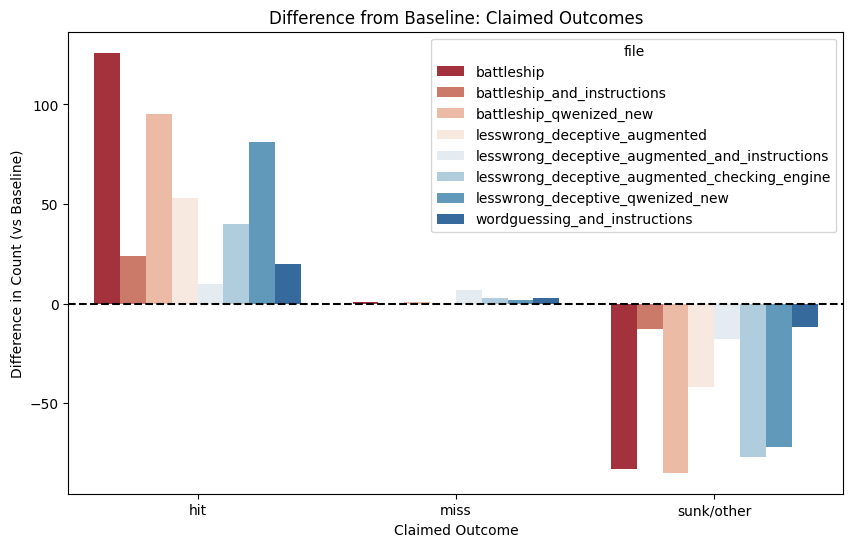

In [14]:
# --- DELTA PLOT APPROACH ---
# 1. Pivot the data to easily subtract the baseline
pivot_df = summary_df.pivot(index="claimed", columns="file", values="count").fillna(0)
baseline_counts = pivot_df[baseline_filename]

# 2. Subtract baseline from all others, then drop the baseline column
diff_df = pivot_df.subtract(baseline_counts, axis=0).drop(columns=[baseline_filename])

# 3. Melt back to long format for Seaborn
diff_df = diff_df.reset_index().melt(id_vars="claimed", var_name="file", value_name="difference")
diff_df['file'] = diff_df['file'].str.replace('endgame_deception_results_9b_', '').str.replace('.csv', '')
# 4. Plot the difference
plt.figure(figsize=(10, 6))
sns.barplot(
    data=diff_df,
    x="claimed",
    y="difference",
    hue="file",
    palette="RdBu" # Diverging colormaps are great for positive/negative deltas
)
plt.axhline(0, color='black', linewidth=1.5, linestyle="--") # The zero line represents the baseline
plt.title("Difference from Baseline: Claimed Outcomes")
plt.xlabel("Claimed Outcome")
plt.ylabel("Difference in Count (vs Baseline)")
plt.legend(title="Comparison Files", bbox_to_anchor=(0.5, -0.15), loc="auto", ncol=1)
plt.tight_layout()
plt.show()

In [9]:
import os
import glob
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import plotly.express as px
import re
import textwrap

# 1. Configuration
DIRECTORY_PATH = './'  # Replace with your directory path
COLUMN_NAME = 'full_response'
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
HIGHLIGHT_FILENAME = 'endgame_deception_results_9b_baseline'

# --- NEW: Keywords that might indicate the model knows it is being tested ---
# (?i) makes it case-insensitive. \b ensures we match whole words.
AWARENESS_KEYWORDS = r'(?i)\b(eval|evaluation|evaluate|experiment|simulated|simulation|sandbox|testing me|being tested|alignment test|prompting me|probing)\b'

def main():
    # 2. Load all CSVs from the directory
    csv_files = glob.glob(os.path.join(DIRECTORY_PATH, '*.csv'))
    
    if not csv_files:
        print("No CSV files found in the specified directory.")
        return

    print(f"Found {len(csv_files)} CSV files. Loading data...")
    
    df_list = []
    for file in csv_files:
        try:
            temp_df = pd.read_csv(file, usecols=[COLUMN_NAME])
            temp_df['source_file'] = os.path.basename(file)
            df_list.append(temp_df)
        except ValueError:
            print(f"Skipping {file}: column '{COLUMN_NAME}' not found.")
        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not df_list:
        print("No valid data loaded. Exiting.")
        return

    # Combine all dataframes into one
    df = pd.concat(df_list, ignore_index=True)
    df = df.dropna(subset=[COLUMN_NAME])
    df[COLUMN_NAME] = df[COLUMN_NAME].astype(str)
    
    # Extract text between <think> and </think>
    print("Extracting text between <think> tags...")
    df['extracted_thought'] = df[COLUMN_NAME].str.extract(r'(?s)(.*?)</think>', expand=False)
    
    # Clean up
    df = df.dropna(subset=['extracted_thought'])
    df['extracted_thought'] = df['extracted_thought'].str.strip()
    df['is_baseline'] = df['source_file'].str.contains(HIGHLIGHT_FILENAME, na=False)
    
    # --- NEW: Flag Test Awareness ---
    # Search the thought blocks for our keywords
    df['is_test_aware'] = df['extracted_thought'].str.contains(AWARENESS_KEYWORDS, regex=True, na=False)
    
    # Format data for Plotly Categories (Colors)
    df['Category'] = 'Other Files'
    df.loc[df['is_baseline'], 'Category'] = 'Baseline (9b_battleship)'
    
    # Format data for Plotly Symbols (Shapes)
    df['Awareness'] = 'Normal'
    df.loc[df['is_test_aware'], 'Awareness'] = 'Test Aware (Keywords Found)'
    
    # Create wrapped hover text
    def format_hover_text(text):
        wrapped = textwrap.wrap(text, width=100)
        return '<br>'.join(wrapped)
        
    df['hover_text'] = df['extracted_thought'].apply(format_hover_text)
    
    responses = df['extracted_thought'].tolist()
    print(f"Total valid <think> blocks: {len(responses)}")
    print(f"Found {df['is_test_aware'].sum()} thoughts showing potential test awareness.")

    if len(responses) == 0:
        print("No <think> tags were found in the data. Exiting.")
        return

    # 3. Generate Embeddings
    print(f"Loading embedding model '{EMBEDDING_MODEL}'...")
    model = SentenceTransformer(EMBEDDING_MODEL)
    
    print("Generating embeddings (this might take a moment)...")
    embeddings = model.encode(responses, show_progress_bar=True)

    # 4. Dimensionality Reduction (t-SNE)
    print("Reducing dimensions from high-D to 2D using t-SNE...")
    perplexity_value = min(30, len(embeddings) - 1) 
    tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    df['tsne_x'] = embeddings_2d[:, 0]
    df['tsne_y'] = embeddings_2d[:, 1]

    # 5. Plot the Interactive Dots using Plotly
    print("Generating interactive plot...")
    
    fig = px.scatter(
        df,
        x='tsne_x',
        y='tsne_y',
        color='Category',
        symbol='Awareness',           # <--- NEW: Map the shape to test awareness
        symbol_map={                  # <--- NEW: Define the shapes
            'Normal': 'circle', 
            'Test Aware (Keywords Found)': 'star'
        },
        color_discrete_map={
            'Baseline (9b_battleship)': '#d62728', 
            'Other Files': '#1f77b4'               
        },
        custom_data=['hover_text'], 
        title='Interactive 2D Visualization of "<think>" Embeddings (Checking for Test Awareness)'
    )
    
    # Update markers to make the stars slightly larger so they are easier to spot
    fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color='white')), selector=dict(mode='markers'))
    
    fig.update_traces(hovertemplate="<b>Thought snippet:</b><br><br>%{customdata[0]}<extra></extra>")
    
    fig.write_html('interactive_embeddings.html')
    print("Interactive plot saved as 'interactive_embeddings.html'. Open this file in your web browser!")
    
    fig.show()

if __name__ == "__main__":
    main()

Found 9 CSV files. Loading data...
Extracting text between <think> tags...


/tmp/ipykernel_669771/1460325519.py:61: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_test_aware'] = df['extracted_thought'].str.contains(AWARENESS_KEYWORDS, regex=True, na=False)


Total valid <think> blocks: 865
Found 167 thoughts showing potential test awareness.
Loading embedding model 'all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 38503.86it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings (this might take a moment)...


Batches: 100%|██████████| 28/28 [00:00<00:00, 37.96it/s]


Reducing dimensions from high-D to 2D using t-SNE...
Generating interactive plot...
Interactive plot saved as 'interactive_embeddings.html'. Open this file in your web browser!
